# Α. Word embeddings

In [2]:
import gensim.downloader as api

In [3]:
wvec_google = api.load("word2vec-google-news-300")

In [3]:
wvec_glove = api.load("glove-wiki-gigaword-300")

[==================================================] 100.0% 376.1/376.1MB downloaded


In [5]:
vec = wvec_google["king"]

In [6]:
len(vec)

300

In [7]:
type(vec)

numpy.ndarray

In [9]:
%%capture
# Ouptuts the embedding vector for word car
# Output layer is 300 neurons so len is 300
wvec_google["car"]

In [10]:
# Word similarity
my_words = ["car", "jaguar", "Jaguar", "facebook"]

In [11]:
def most_similar_words_from_model(model, words, n=10):
    similar = {}
    for w in words:
        similar[w] = {}
        try:
            # print(w)
            ms = model.most_similar(positive=[w], topn=n)
            similar[w] = ms
        except KeyError:
            print(f"Word: {w} not found")
    return similar

In [13]:
smw_google = most_similar_words_from_model(wvec_google, my_words)
smw_glove = most_similar_words_from_model(wvec_glove, my_words)

Word: Jaguar not found


In [14]:
def extract_word_list(similars):
  return [ p[0] for k in similars.keys() for p in similars[k] ]

In [15]:
words_google = extract_word_list(smw_google)
words_glove = extract_word_list(smw_glove)

In [16]:
def return_list_intersection(list1, list2):
  return list(set(list1) & set(list2))

In [19]:
def task1(word_list, n=10):
    # Extract similar words
    smw_google = most_similar_words_from_model(wvec_google, word_list, n=n)
    smw_glove = most_similar_words_from_model(wvec_glove, word_list)

    # Extract word list
    words_google = extract_word_list(smw_google)
    words_glove = extract_word_list(smw_glove)

    # Find intersection
    intersection_list = return_list_intersection(words_google, words_glove)

    print(f"Common words: {intersection_list}\nLength: {len(intersection_list)}")

In [20]:
task1(my_words)

Word: Jaguar not found
Common words: ['twitter', 'linkedin', 'truck', 'vehicle', 'myspace', 'cars']
Length: 6


---

task 2

In [22]:
mywords = ["simulation", "singularity", "matrix", "lecturer"]
task1(mywords)

Common words: ['simulator', 'simulate', 'simulators', 'simulating', 'simulated', 'simulations', 'matrices', 'spacetime', 'singularities', 'professor']
Length: 10


---

task 3

Closest words to word student - glove

In [25]:
# Glove
most_similar_words_from_model(model=wvec_glove, words=["student"], n=10)

{'student': [('students', 0.7690913677215576),
  ('teacher', 0.6873654723167419),
  ('graduate', 0.6737601161003113),
  ('school', 0.6130647659301758),
  ('college', 0.6090279221534729),
  ('undergraduate', 0.6043776273727417),
  ('faculty', 0.599898636341095),
  ('university', 0.5970513224601746),
  ('academic', 0.5810065865516663),
  ('campus', 0.5767688155174255)]}

In [27]:
# Google
most_similar_words_from_model(model=wvec_google, words=["student"], n=10)

{'student': [('students', 0.7294867038726807),
  ('Student', 0.6706662774085999),
  ('teacher', 0.6301366090774536),
  ('stu_dent', 0.6240993142127991),
  ('faculty', 0.6087332963943481),
  ('school', 0.6055627465248108),
  ('undergraduate', 0.6020305752754211),
  ('university', 0.600540041923523),
  ('undergraduates', 0.5755698680877686),
  ('semester', 0.573759913444519)]}

In [32]:
def find_unrelated_embeddings(model, word, word_list):
  orig_embed = model[word]

  for aw in word_list:
      try:
          e = model[aw]
          orig_embed = orig_embed - e
      except KeyError:
        print(f"Not present: {aw}")
          
  return orig_embed

In [33]:
# Find words unrelated to university students - Google
wvec_google.similar_by_vector(find_unrelated_embeddings(wvec_google, "student", ["university"]))

[('student', 0.5257112979888916),
 ('sixth_grader', 0.4625338912010193),
 ('seventh_grader', 0.4439777433872223),
 ('8th_grader', 0.4418715834617615),
 ('eighth_grader', 0.4347041845321655),
 ('grader', 0.42413344979286194),
 ('kindergartner', 0.421089231967926),
 ('kindergartener', 0.4035879075527191),
 ('teacher', 0.37846359610557556),
 ('Kindergartner', 0.3726333677768707)]

In [39]:
# Find words unrelated to university students - Glove
wvec_glove.similar_by_vector(find_unrelated_embeddings(wvec_glove, "student", ["campus"]))

[('student', 0.46648210287094116),
 ('teacher', 0.4348181486129761),
 ('17-year', 0.3734218180179596),
 ('23-year', 0.35940542817115784),
 ('16-year', 0.3574991524219513),
 ('pupil', 0.3572327196598053),
 ('16-year-old', 0.3553757965564728),
 ('teenager', 0.3416033685207367),
 ('14-year-old', 0.3410041034221649),
 ('15-year', 0.3375958502292633)]

In [44]:
# Exclude teenagers and undergraduates from results - Glove
wvec_glove.similar_by_vector(find_unrelated_embeddings(wvec_glove, "student", ["kindergartner"]))

[('student', 0.7252743244171143),
 ('students', 0.5951646566390991),
 ('university', 0.5806416273117065),
 ('members', 0.5308770537376404),
 ('faculty', 0.5241250991821289),
 ('college', 0.5054463744163513),
 ('also', 0.5041286945343018),
 ('campus', 0.5031340718269348),
 ('graduate', 0.4950902462005615),
 ('and', 0.49262112379074097)]

In [51]:
# Exclude teenagers and undergraduates from results - Google
wvec_google.similar_by_vector(find_unrelated_embeddings(wvec_google, "student", ["eighth_grader"]))

[('university', 0.4033023715019226),
 ('student', 0.35543668270111084),
 ('faculty', 0.3501347601413727),
 ('univeristy', 0.34368154406547546),
 ('lecturers', 0.3419628143310547),
 ('Faculty', 0.33087217807769775),
 ('professors', 0.32864975929260254),
 ('UoE', 0.32346633076667786),
 ('nontenured_faculty', 0.3227248787879944),
 ('semesterly', 0.3224186599254608)]

---

task 4

Find 2 most related words to the sequences:

In [52]:
# Google
print(wvec_google.similar_by_vector(wvec_google["king"] - wvec_google["man"] + wvec_google["woman"], topn=2))
print(wvec_google.similar_by_vector(wvec_google["France"] - wvec_google["Paris"] + wvec_google["Tokyo"], topn=2))
print(wvec_google.similar_by_vector(wvec_google["trees"] - wvec_google["apples"] + wvec_google["grapes"], topn=2))
print(wvec_google.similar_by_vector(wvec_google["doctor"] - wvec_google["father"] + wvec_google["mother"], topn=2))

[('king', 0.8449392318725586), ('queen', 0.7300517559051514)]
[('Japan', 0.8330698013305664), ('Tokyo', 0.7668523192405701)]
[('trees', 0.7491557598114014), ('vines', 0.7059928774833679)]
[('doctor', 0.881921648979187), ('nurse', 0.7165823578834534)]


In [54]:
# Glove
# Here we expect the words "queen"
print(wvec_glove.similar_by_vector(wvec_glove["king"] - wvec_glove["man"] + wvec_glove["woman"], topn=2))

# We are asking for the country with capital Tokyo
print(wvec_glove.similar_by_vector(wvec_glove["france"] - wvec_glove["paris"] + wvec_glove["tokyo"], topn=2))

# We are asking for the name of the tree structure of grapes.
print(wvec_glove.similar_by_vector(wvec_glove["trees"] - wvec_glove["apples"] + wvec_glove["grapes"], topn=2))

# We are asking the medical profession related to a woman?
print(wvec_glove.similar_by_vector(wvec_glove["doctor"] - wvec_glove["father"] + wvec_glove["mother"], topn=2))

[('king', 0.8065858483314514), ('queen', 0.689616322517395)]
[('japan', 0.8084266781806946), ('tokyo', 0.7096843719482422)]
[('trees', 0.7323408126831055), ('vines', 0.5982635021209717)]
[('doctor', 0.8397707343101501), ('nurse', 0.6648029088973999)]


---

task 5

Constructing own analogies.

In [76]:
# analogy for Rome
print(wvec_google.similar_by_vector(wvec_google["Athens"] - wvec_google["Greece"] + wvec_google["Italy"], topn=2))

# Analogy for brother
print(wvec_glove.similar_by_vector(wvec_glove["boy"] - wvec_glove["girl"] + wvec_glove["sister"], topn=2))

#
print(wvec_google.similar_by_vector(wvec_google["doctor"] - wvec_google["hospital"] + wvec_google["school"], topn=3))

[('Rome', 0.6179379820823669), ('Italy', 0.5662806034088135)]
[('sister', 0.8131285905838013), ('brother', 0.7375139594078064)]
[('school', 0.5947734713554382), ('guidance_counselor', 0.5738599300384521), ('teacher', 0.5409977436065674)]


---

task 6

In [189]:
from sklearn.decomposition import IncrementalPCA 
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import random

In [190]:
def reduce_dimensions(model, words, perplexity=3, nof_dims=2):

    # extract the words & their vectors, as numpy arrays
    word_vectors = [model[w] for w in words]
    vectors = np.asarray(word_vectors)

    # reduce using t-SNE
    tsne = TSNE(n_components=nof_dims, random_state=0, perplexity=perplexity)
    vectors = tsne.fit_transform(vectors)

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels

In [191]:
def plot_with_matplotlib(x_vals, y_vals, labels):


    plt.figure(figsize=(12, 12))
    plt.scatter(x_vals, y_vals)

    # Plug labels to points
    for i in range(len(labels)):
        plt.annotate(labels[i], (x_vals[i], y_vals[i]))

In [192]:
abow = ["business", "career", "classroom", "company", "curriculum", "degree", "employee", "exam",
"government", "homework", "investment", "job", "learning", "lecture", "lesson", "manager",
"market", "office", "profession", "research", "salary", "school", "stock", "student", "teacher",
"technology", "training", "university"]

In [193]:
x_vals, y_vals, labels = reduce_dimensions(wvec_glove, abow)

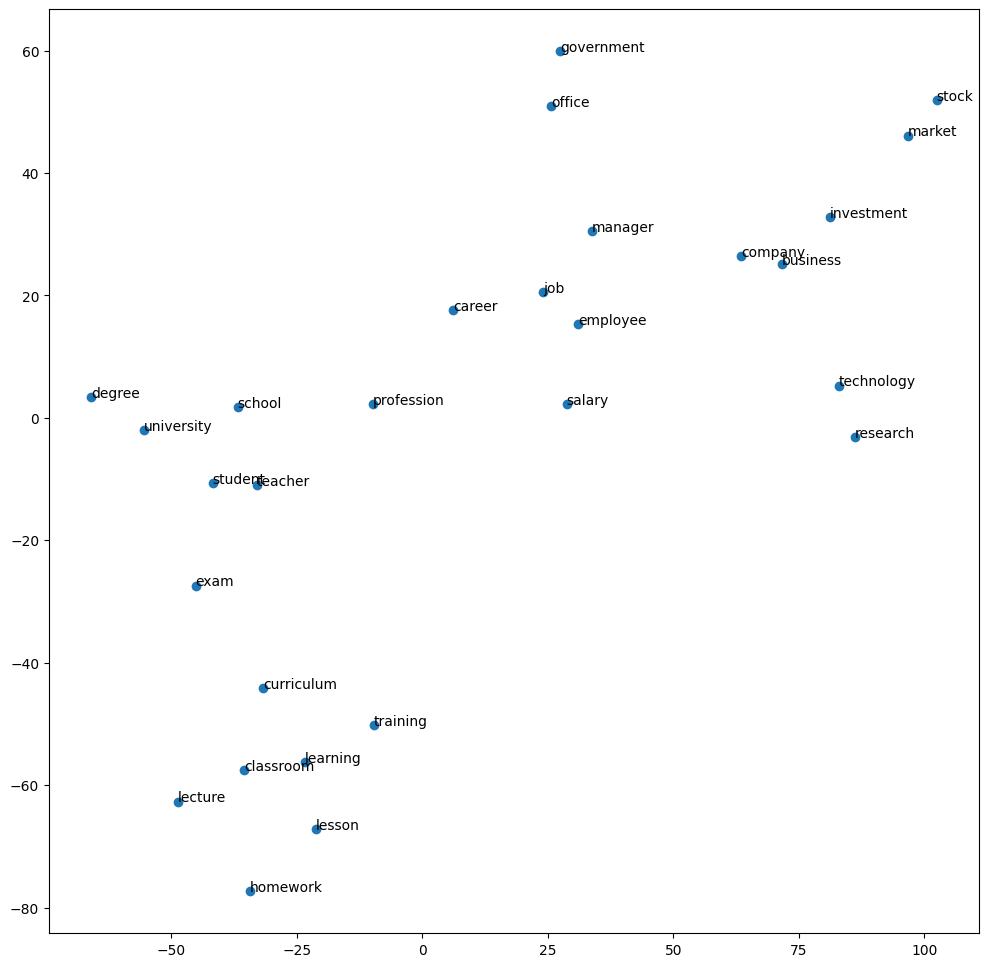

In [194]:
plot_function = plot_with_matplotlib
# else:
#     plot_function = plot_with_plotly
plot_function(x_vals, y_vals, abow)

Results:

In the diagram, we can see how words of similar contextual meaning are clustered in the diagram. This happens because the model we've used to retrieve the embeddings from (Glove) was trained on a corpus in which these words were usually found in the same context. From this context, the model created word embedding whose distance is kind of close to each other.

Clear example are the words: "curriculum", "training", "learning", "classroom",  "lecture", "lesson", and "homework" all seem to cluster to each other.

We can further verify our statement by pulling the closes word embeddings to one of the words in the cluster, preferrably the one in the center of the cluster - "learning". We should be able to match more words from our list by increasing the `topn` variable.

In [1]:
set([p[0] for p in wvec_glove.most_similar(positive="learning", topn=30)]) & set(["curriculum", "training", "learning", "classroom",  "lecture", "lesson",  "homework"])

NameError: name 'wvec_glove' is not defined

---